In [3]:
library(readxl)
library(gamlss)
library(writexl)
library(dplyr)
library(ggplot2)
library(tidyr)

In [4]:
data_path = read_xlsx("/home/okta/Documents/the-curious-analyst/kurva_pertumbuhan/Jungkat/data/data.xlsx", sheet = "male")

In [5]:
data = data_path
head(data)

fnum,age,bw,bh,bh (m),bmi
<chr>,<dbl>,<dbl>,<dbl>,<lgl>,<lgl>
A003,12.5,10.0,76.0,NA,NA
A006,32.5,11.6,86.2,NA,NA
A007,12.5,8.2,72.0,NA,NA
A009,47.5,16.4,96.4,NA,NA
A010,11.5,8.5,76.5,NA,NA
A012,21.5,9.8,82.0,NA,NA


As we can see above, the columns `bh (m)` and `bmi` are not needed. So I can just delete both columns. 

## Data Profiling

In [6]:
data[, c("bmi", "bh (m)")] <- list(NULL) # delete both columns bh (m) and bmi
colnames(data)

[1] "fnum" "age"  "bw"   "bh"

We need body height in meters in order to calculate bmi. Therefore, I will make new column named `bh_m` to store the `bh` in meters by dividing the `bh` to 100.

In [7]:
data$bh_m <- data$bh / 100.0 # calculate bh in meters
head(data)

fnum,age,bw,bh,bh_m
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
A003,12.5,10.0,76.0,0.760
A006,32.5,11.6,86.2,0.862
A007,12.5,8.2,72.0,0.720
A009,47.5,16.4,96.4,0.964
A010,11.5,8.5,76.5,0.765
A012,21.5,9.8,82.0,0.820


We now have the value we need to calculate BMI.  We can now calculate bmi with the following formula:
$$\text{BMI}=\frac{\text{weight\ (kg)}}{[\text{height\ (m)}]^{2}}$$

In [8]:
data$bmi <- data$bw / (data$bh_m)**2
head(data)

fnum,age,bw,bh,bh_m,bmi
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A003,12.5,10.0,76.0,0.760,17.31302
A006,32.5,11.6,86.2,0.862,15.61146
A007,12.5,8.2,72.0,0.720,15.81790
A009,47.5,16.4,96.4,0.964,17.64777
A010,11.5,8.5,76.5,0.765,14.52433
A012,21.5,9.8,82.0,0.820,14.57466


In [9]:
male_summary <- data %>%
                    select(bh, bw) %>%
                    summarise(across(everything(),
                                     list(
                                         n = ~n(),
                                         mean = ~mean(., na.rm=TRUE),
                                         sd = ~sd(., na.rm=TRUE),
                                         median = ~median(., na.rm=TRUE),
                                         #trimmed = ~mean(., trim = 0.1, na.rm = TRUE),
                                         #mad = ~mad(., na.rm = TRUE),
                                         #min = ~min(., na.rm = TRUE),
                                         #max = ~max(., na.rm = TRUE),
                                         #range = ~diff(range(., na.rm = TRUE)),
                                         skew = ~moments::skewness(., na.rm = TRUE),
                                         kurtosis = ~moments::kurtosis(., na.rm = TRUE),
                                         se = ~sd(., na.rm = TRUE)/sqrt(sum(!is.na(.)))
                                        ))) %>%
                    pivot_longer(everything(), names_to = c("variable", "stat"), names_sep = "_") %>%
                    pivot_wider(names_from = "variable", values_from = "value") %>%
                    select(stat, bh, bw) %>%
                    mutate(across(c(bh, bw), ~round(., 2)))

In [10]:
male_summary

stat,bh,bw
<chr>,<dbl>,<dbl>
n,213.00,213.00
mean,83.65,11.04
sd,13.70,3.43
median,83.00,10.60
skew,-0.02,0.33
kurtosis,2.17,2.91
se,0.94,0.24


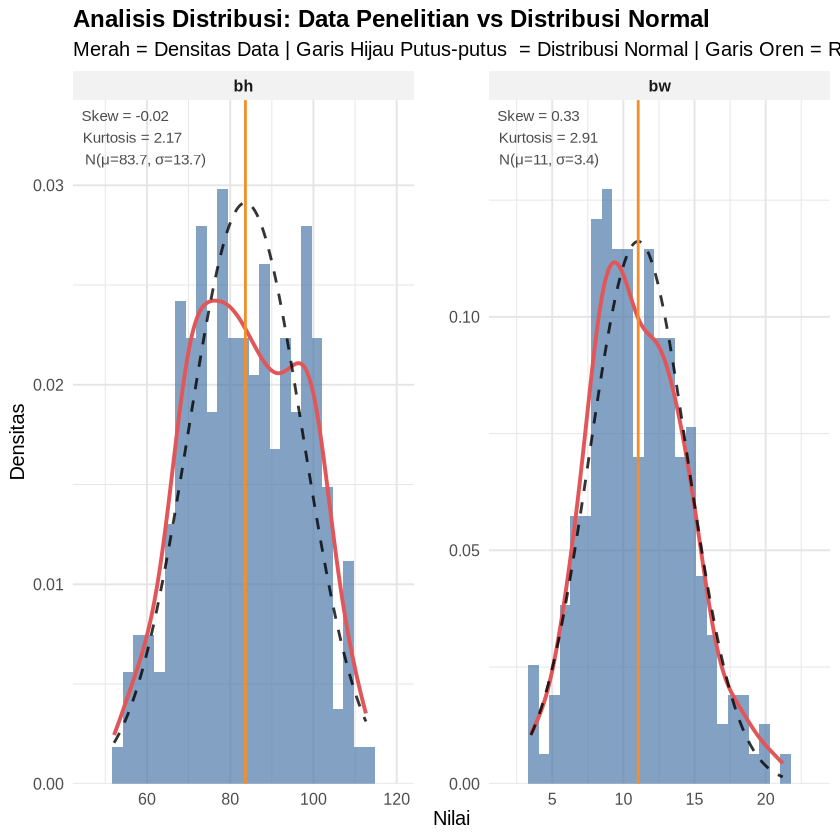

In [11]:
stats_male <- data %>%
  summarise(
    bh_mean = mean(bh, na.rm = TRUE),
    bh_skew = moments::skewness(bh, na.rm = TRUE),
    bh_kurt = moments::kurtosis(bh, na.rm = TRUE),
    bw_mean = mean(bw, na.rm = TRUE),
    bw_skew = moments::skewness(bw, na.rm = TRUE),
    bw_kurt = moments::kurtosis(bw, na.rm = TRUE)
  )

# Menghitung kurva normal secara terpisah 
# Membuat data kurva normal
bh_norm <- data.frame(
  variable = "bh",
  x = seq(min(data$bh, na.rm = TRUE), max(data$bh, na.rm = TRUE), length.out = 200),
  y = dnorm(seq(min(data$bh, na.rm = TRUE), max(data$bh, na.rm = TRUE), length.out = 200), 
            mean = stats_male$bh_mean, 
            sd = sd(data$bh, na.rm = TRUE))
)

bw_norm <- data.frame(
  variable = "bw",
  x = seq(min(data$bw, na.rm = TRUE), max(data$bw, na.rm = TRUE), length.out = 200),
  y = dnorm(seq(min(data$bw, na.rm = TRUE), max(data$bw, na.rm = TRUE), length.out = 200), 
            mean = stats_male$bw_mean, 
            sd = sd(data$bw, na.rm = TRUE))
)

normal_curves <- bind_rows(bh_norm, bw_norm)

# Membuat plot
male_density <- data %>%
  select(bh, bw) %>%
  pivot_longer(everything(), names_to = "variable", values_to = "value") %>%
  ggplot(aes(x = value)) +
  geom_histogram(aes(y = after_stat(density)), 
                 bins = 25, 
                 fill = "#4E79A7", 
                 alpha = 0.7) +
  geom_density(color = "#E15759", linewidth = 1.1) +
  # Menambahkan referensi distribusi normal
  geom_line(data = normal_curves, 
            aes(x = x, y = y),
            color = "#020203", 
            linetype = "dashed",
            linewidth = 0.8,
            alpha = 0.8) +
  facet_wrap(~ variable, scales = "free", ncol = 2) +
  # Menambahkan garis mean
  geom_vline(data = data.frame(variable = "bh", xint = stats_male$bh_mean),
             aes(xintercept = xint), color = "#F28E2B", linetype = "solid", linewidth = 0.8) +
  geom_vline(data = data.frame(variable = "bw", xint = stats_male$bw_mean),
             aes(xintercept = xint), color = "#F28E2B", linetype = "solid", linewidth = 0.8) +
  # text anotasi
  geom_text(data = data.frame(variable = "bh", 
                              label = paste0("Skew = ", round(stats_male$bh_skew, 2), 
                                           "\nKurtosis = ", round(stats_male$bh_kurt, 2),
                                           "\nN(μ=", round(stats_male$bh_mean, 1), 
                                           ", σ=", round(sd(data$bh, na.rm = TRUE), 1), ")")),
            aes(x = -Inf, y = Inf, label = label),
            hjust = -0.1, vjust = 1.2, size = 3.2, color = "gray30") +
  geom_text(data = data.frame(variable = "bw", 
                              label = paste0("Skew = ", round(stats_male$bw_skew, 2), 
                                           "\nKurtosis = ", round(stats_male$bw_kurt, 2),
                                           "\nN(μ=", round(stats_male$bw_mean, 1), 
                                           ", σ=", round(sd(data$bw, na.rm = TRUE), 1), ")")),
            aes(x = -Inf, y = Inf, label = label),
            hjust = -0.1, vjust = 1.2, size = 3.2, color = "gray30") +
  scale_x_continuous(expand = expansion(mult = 0.15)) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +  # Slightly more top margin
  theme_minimal(base_size = 12) +
  labs(
    title = "Analisis Distribusi: Data Penelitian vs Distribusi Normal",
    subtitle = "Merah = Densitas Data | Garis Hijau Putus-putus  = Distribusi Normal | Garis Oren = Rerata",
    x = "Nilai",
    y = "Densitas"
  ) +
  theme(
    plot.title = element_text(face = "bold"),
    strip.background = element_rect(fill = "gray95", color = NA),
    strip.text = element_text(face = "bold"),
    panel.spacing = unit(1.5, "lines"),
    panel.grid = element_line(color = "gray90")
  )

male_density

In [12]:
data$age_year <- (data$age / 12)
head(data)

fnum,age,bw,bh,bh_m,bmi,age_year
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A003,12.5,10.0,76.0,0.760,17.31302,1.0416667
A006,32.5,11.6,86.2,0.862,15.61146,2.7083333
A007,12.5,8.2,72.0,0.720,15.81790,1.0416667
A009,47.5,16.4,96.4,0.964,17.64777,3.9583333
A010,11.5,8.5,76.5,0.765,14.52433,0.9583333
A012,21.5,9.8,82.0,0.820,14.57466,1.7916667


`geom_smooth()` using formula = 'y ~ x'


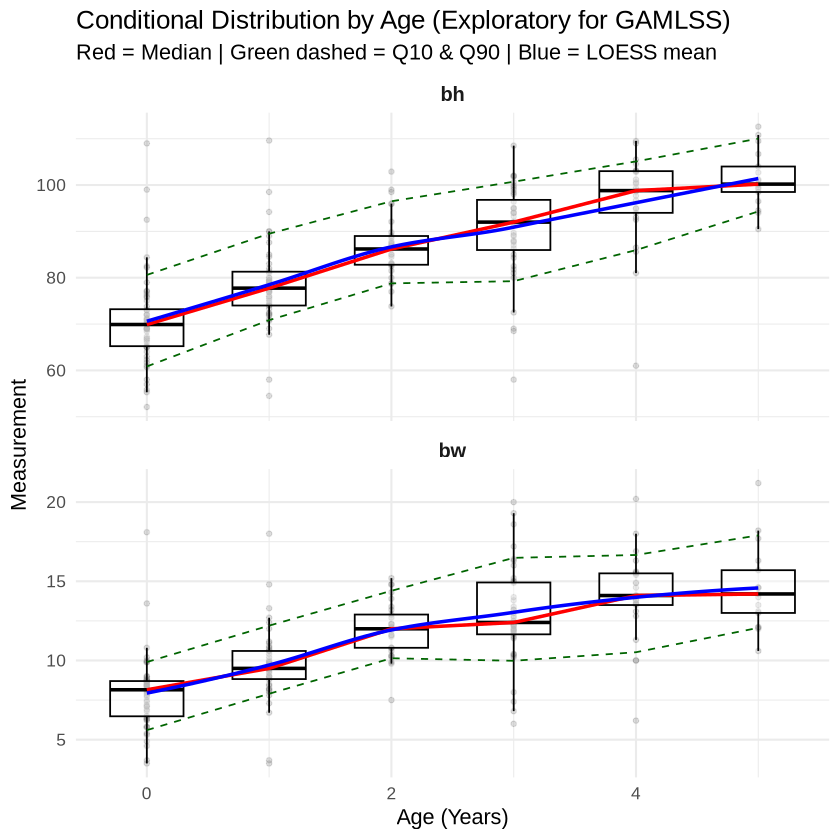

In [13]:
male_scatterplot <- data %>%
  select(age_year, bh, bw) %>%
  pivot_longer(cols = c(bh, bw),
               names_to = "variable",
               values_to = "value") %>%
  mutate(
    age_int = floor(age_year),  # pastikan umur integer untuk grouping
    age_group = factor(age_int)
  ) %>%
  ggplot(aes(x = age_int, y = value)) +
  
  # Scatter data mentah
  geom_point(alpha = 0.25, size = 1.2, color = "gray50") +
  
  # Boxplot per umur
  geom_boxplot(aes(group = age_group),
               width = 0.6,
               alpha = 0.4,
               outlier.shape = NA,
               color = "black") +
  
  # Garis median per umur (lebih tegas dari boxplot)
  stat_summary(fun = median,
               geom = "line",
               color = "red",
               linewidth = 1) +
  
  # Garis quantile kasar (indikasi spread & skew)
  stat_summary(fun = function(x) quantile(x, 0.10),
               geom = "line",
               color = "darkgreen",
               linetype = "dashed") +
  
  stat_summary(fun = function(x) quantile(x, 0.90),
               geom = "line",
               color = "darkgreen",
               linetype = "dashed") +
  
  # LOESS untuk melihat struktur mean non-linear
  geom_smooth(method = "loess",
              color = "blue",
              se = FALSE,
              linewidth = 1) +
  
  facet_wrap(~ variable, scales = "free_y", ncol = 1) +
  
  theme_minimal(base_size = 13) +
  labs(
    title = "Conditional Distribution by Age (Exploratory for GAMLSS)",
    subtitle = "Red = Median | Green dashed = Q10 & Q90 | Blue = LOESS mean",
    x = "Age (Years)",
    y = "Measurement"
  ) +
  theme(
    strip.text = element_text(face = "bold", size = 12)
  )

male_scatterplot

The plot above tells us several important points as follows:
#### 1) Component 1: Location ($\mu$)
The location parameter typically models the trend of the center of the distribution (the conditional mean or median) across time. If we look closely at the alignment of the red line (median) and the blue line (LOESS mean), we can conclude the following:
- In the body height (bh), both lines are visually identical across all 5 years.
- In the body weight (bw), they visually identical early on until the age of 2, the blue line, the mean starts to hovers slightly above the median line. This means that the body weight data is right-skewed or positively-skewed. This means that the dataset has few exceptionally high values Instead of a balanced, bell-shaped curve, the data stretches out longer toward the higher numbers, pulling the mean upward while the median stays anchored in the middle.

#### 2) Component 2: Scale ($\sigma$)
The scale parameter models the statistical dispersion (variance or variability) as a function of the explanatory variable (age). Visually, we track this by looking at the vertical distance between the two green dashed lines (__Q10__ and __Q90__) and the height of the boxes from age 0 to 5. 
* Look at bh: The vertical distance between the top and bottom green lines remains relatively uniform from birth to age 5. The absolute spread doesn't change drastically.  
* Look at bw: Notice the gap between the green lines at age 0 versus the gap at age 5. It widens, creating a subtle "funnel" or "trumpet" shape.

#### 3) Component 3: Investigating Shape ($\nu$ for Skewness, $\tau$ for Kurtosis)
Shape parameters handle deviations from normality—specifically asymmetry (skewness) and heavy/light tails (kurtosis). In order to inspect this visually, we need to look at the individual gray data points (outliers) and the structure of the boxplots. 
- First, if we look at bw at age 3, the whiskers stretch far upward compared to downward.
- Second, if we look at the black line inside the box, representing the median line, the line is much closer to the bottom of the box, leaving much more space at the top. This means that the data distribution does not follow the standard gaussian (normal) distribution. Therefore, if we try to use and force standard gaussian distribution on this data, the model will not accurately predict the top percentile of the data.

#### Conclusions
There are several important information based on the scatterplot as follows:
- If the variance of a data changes across the explanatory variable, the parameter cannot be constant.
- In GAMLSS, we use penalized smoothing splines, specifically __P-Splines__ (`pb()`), because they automatically optimize the degrees of freedom using Generalized Akaike Information Criterion (GAIC) or local Maximum Likelihood.
- For body height,  $\mu$ (Location) changes non-linearly with age: `mu.formula = ~ pb(age)`
- $\sigma$ (Scale) looks visually stable in absolute terms, but as children grow, a constant coefficient of variation is often safer. We can test a constant first: `sigma.formula = ~ 1`
- For Body Weight (bw), $\mu$ (Location) curves heavily: `mu.formula = ~ pb(age)`
- $\sigma$ (Scale) expands like a funnel: `sigma.formula = ~ pb(age)`
- $\nu$ (Skewness) changes as children age and eating habits diverge: `nu.formula = ~ pb(age) (or a linear trend ~ age)`

#### Choosing Distribution Family
Since our data displays clear skewness and potential tail-heaviness (kurtosis) in weight, we need families that go beyond the 2-parameter Gaussian. Therefore, here are the primary mathematical candidates for the model of our data:
1) BCCG (Box-Cox Cole-Green), 3 parameters ($\mu, \sigma, \nu$), best suited for height/basic weight: handles skewness ($\nu$) perfectly, but assumes standard normal kurtosis after transformation.
2) BCPE (Box-Cox Power Exponential), 4 parameters ($\mu, \sigma, \nu, \tau$), best suited for weight with outliers: Handles skewness ($\nu$) and adjusts the tails ($\tau$) if they are heavier/lighter than a normal distribution.
3) BCT (Box-Cox t), 4 parameters ($\mu, \sigma, \nu, \tau$), best suited for rigorous growth curves: Similar to BCPE, but uses a student-$t$ base for the tails. This is what the World Health Organization (WHO) typically uses for weight standards because it handles extreme outliers gracefully.

In [63]:
ggsave("../plot/male_scatter.png", male_scatterplot, 
       width = 12, height = 8, dpi = 1200,
       bg="white")  # 2:1 ratio

`geom_smooth()` using formula = 'y ~ x'


In [14]:
binned_summary <- data %>%
  mutate(
    # Create 6-month intervals from 0 to 60 months
    age_bin = cut(age, breaks = seq(0, 72, by = 6), include.lowest = TRUE)
  ) %>%
  group_by(age_bin) %>%
  summarise(
    n = n(),
    mean_bw = mean(bw, na.rm = TRUE),
    sd_bw   = sd(bw, na.rm = TRUE),
    # Using e1071 or moments package for skewness/kurtosis
    skew_bw = moments::skewness(bw, na.rm = TRUE),
    kurt_bw = moments::kurtosis(bw, na.rm = TRUE)
  )

print(binned_summary)

# A tibble: 12 × 6
   age_bin     n mean_bw sd_bw  skew_bw kurt_bw
   <fct>   <int>   <dbl> <dbl>    <dbl>   <dbl>
 1 [0,6]      19    6.92  2.10  1.86       6.50
 2 (6,12]     37    8.46  2.18  1.83      12.5 
 3 (12,18]    25    9.16  2.62  0.844      7.48
 4 (18,24]    21   10.4   1.84  0.570      3.26
 5 (24,30]    17   11.6   1.95  0.00236    2.57
 6 (30,36]    12   12.4   1.32  0.782      2.87
 7 (36,42]    23   12.3   2.45  0.505      4.17
 8 (42,48]    17   13.6   3.76 -0.376      2.84
 9 (48,54]    14   13.7   1.89 -0.633      3.20
10 (54,60]    11   14.6   3.62 -0.881      3.97
11 (60,66]     7   15.7   3.16  0.674      2.31
12 (66,72]    10   13.8   2.03  0.353      2.68


### Analysis
#### Location ($\mu$)
- `mean_bw` climbs rapidly from 6.92 kg to 10.4 kg in the first 24 months, then slows down to a steadier linear increase up to 15.7 at 66 months but then decreasing to 13.8 at 72 months.
- This confirms that location parameter $\mu$ is non-linear, therefore a simple linear term will fail. We must use a penalized smoothing spline: `mu.formula = ~ pb(age)`.

#### Scale ($\sigma$)
- The standard deviation (`sd_bw`) starts around 2.10, then drops slightly until 36 months. After 36 months, it went up to 3.76 at 48 months. Then drops and then up again to 3.62 at 60 months.
- The variance is clearly _heteroscedastic_ (non-constant). Because the variability changes shapes across the age axis, $\sigma$ cannot be a constant. It needs its own functional form: `sigma.formula = ~ pb(age)`.

#### Skewness ($\nu$)
- Look at how `skew_bw` behaves over time
- From 0 to 12 months, skewness is extremely high ($\approx 1.86$). The data has a massive right tail.
- From 12 to 42 months, it stabilizes into a moderate positive skew ($\approx 0.50$ to $0.84$).
- After 42 months, the skewness flips signs entirely, becoming negative ($-0.37$ down to $-0.88$).
- Conclusion: This is a crucial finding. The distribution doesn't just have skewness; the direction of the asymmetry changes as the children grow. If we treat $\nu$ as a constant, our growth curve will completely miscalculate the upper percentiles for infants and the lower percentiles for 5-year-olds. $\nu$ must be modeled as a function of age: `nu.formula = ~ pb(age)`.

#### Kurtosis ($\tau$)
-  In a standard normal distribution, kurtosis is $3.0$. In your early bins ([0,6], (6,12], (12,18]), the kurtosis numbers are astronomical ($6.50$, $12.5$, and $7.48$). This indicates a highly leptokurtic distribution—meaning the data has a very sharp central peak and exceptionally heavy tails (extreme outliers) during infancy. Later on, it settles down closer to normal levels ($\approx 2.5$ to $4.0$).
-  Conclusion: A 3-parameter distribution like BCCG (Box-Cox Cole-Green), which assumes a fixed kurtosis after transformation, will struggle to accommodate a local kurtosis of $12.5$. You absolutely require a 4-parameter distribution family that explicitly optimizes the tail parameter $\tau$.

#### Mathematical Blueprint
Based on the empirical data, we can formally outline the ideal GAMLSS structure for your body weight growth curve:
- Distribution Family: BCT (Box-Cox $t$) or BCPE (Box-Cox Power Exponential). The BCT is highly recommended here because its underlying Student-$t$ distribution handles heavy tails and extreme leptokurtosis better than almost any other family.
- Functional Architecture:
$$\mu \sim pb(\text{age})$$$$\sigma \sim pb(\text{age})$$$$\nu \sim pb(\text{age})$$$$\tau \sim pb(\text{age})$$

## Model Estimation and Parametric Selection

In [15]:
model_full_bct <- gamlss(bw ~ pb(age), 
                         sigma.fo = ~ pb(age), 
                         nu.fo = ~ pb(age), 
                         tau.fo = ~ pb(age), 
                         family = BCT, data = data)

GAMLSS-RS iteration 1: Global Deviance = 939.9105 
GAMLSS-RS iteration 2: Global Deviance = 931.445 
GAMLSS-RS iteration 3: Global Deviance = 928.2104 
GAMLSS-RS iteration 4: Global Deviance = 926.6686 
GAMLSS-RS iteration 5: Global Deviance = 925.8195 
GAMLSS-RS iteration 6: Global Deviance = 925.354 
GAMLSS-RS iteration 7: Global Deviance = 925.1077 
GAMLSS-RS iteration 8: Global Deviance = 924.9777 
GAMLSS-RS iteration 9: Global Deviance = 924.9101 
GAMLSS-RS iteration 10: Global Deviance = 924.8762 
GAMLSS-RS iteration 11: Global Deviance = 924.8604 
GAMLSS-RS iteration 12: Global Deviance = 924.8528 
GAMLSS-RS iteration 13: Global Deviance = 924.8488 
GAMLSS-RS iteration 14: Global Deviance = 924.8463 
GAMLSS-RS iteration 15: Global Deviance = 924.8448 
GAMLSS-RS iteration 16: Global Deviance = 924.8441 


In [16]:
model_const_tau1 <- gamlss(bw ~ pb(age), 
                          sigma.fo = ~ pb(age), 
                          nu.fo = ~ pb(age), 
                          tau.fo = ~ 1, 
                          family = BCT, 
                          data = data,
                          control = gamlss.control(n.cyc = 100))

GAMLSS-RS iteration 1: Global Deviance = 940.5048 
GAMLSS-RS iteration 2: Global Deviance = 931.5788 
GAMLSS-RS iteration 3: Global Deviance = 928.4576 
GAMLSS-RS iteration 4: Global Deviance = 927.358 
GAMLSS-RS iteration 5: Global Deviance = 926.8109 
GAMLSS-RS iteration 6: Global Deviance = 926.3668 
GAMLSS-RS iteration 7: Global Deviance = 926.081 
GAMLSS-RS iteration 8: Global Deviance = 925.912 
GAMLSS-RS iteration 9: Global Deviance = 925.8039 
GAMLSS-RS iteration 10: Global Deviance = 925.73 
GAMLSS-RS iteration 11: Global Deviance = 925.6768 
GAMLSS-RS iteration 12: Global Deviance = 925.6426 
GAMLSS-RS iteration 13: Global Deviance = 925.6186 
GAMLSS-RS iteration 14: Global Deviance = 925.6019 
GAMLSS-RS iteration 15: Global Deviance = 925.5882 
GAMLSS-RS iteration 16: Global Deviance = 925.5769 
GAMLSS-RS iteration 17: Global Deviance = 925.5672 
GAMLSS-RS iteration 18: Global Deviance = 925.5593 
GAMLSS-RS iteration 19: Global Deviance = 925.552 
GAMLSS-RS iteration 20: Glo

In [17]:
GAIC(model_full_bct, model_const_tau1)

,df,AIC
,<dbl>,<dbl>
model_const_tau1,9.708258,944.9050
model_full_bct,10.788196,946.4205


In [39]:
summary(model_const_tau1)

******************************************************************
Family:  c("BCT", "Box-Cox t") 

Call:  gamlss(formula = bw ~ pb(age), sigma.formula = ~pb(age),  
    nu.formula = ~pb(age), tau.formula = ~1, family = BCT,  
    data = data, control = gamlss.control(n.cyc = 100)) 

Fitting method: RS() 

------------------------------------------------------------------
Mu link function:  identity
Mu Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 6.943418   0.185449   37.44   <2e-16 ***
pb(age)     0.133680   0.007058   18.94   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

------------------------------------------------------------------
Sigma link function:  log
Sigma Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -2.009037   0.171618 -11.706   <2e-16 ***
pb(age)     -0.001250   0.004702  -0.266    0.791    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

----------

## Diagnostics

#### 1) Normalized quantile residual of a fitted gamls object

******************************************************************
	      Summary of the Quantile Residuals
                           mean   =  0.02668858 
                       variance   =  0.9937712 
               coef. of skewness  =  0.01758506 
               coef. of kurtosis  =  2.743787 
Filliben correlation coefficient  =  0.997438 
******************************************************************


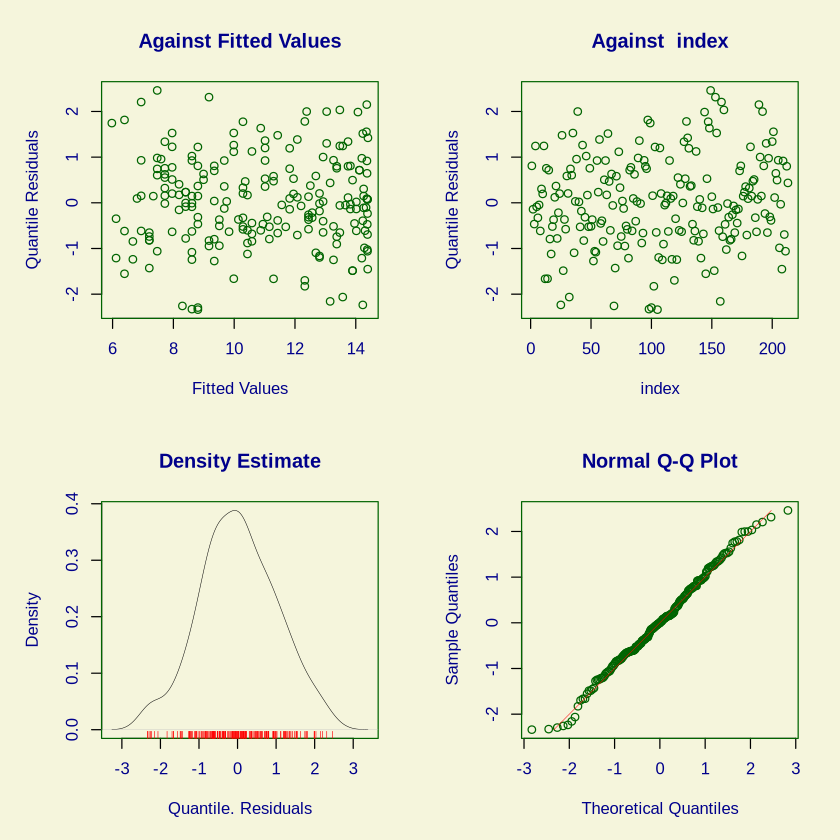

In [22]:
plot(model_const_tau1)

#### 2) Worm Plot

number of missing points from plot= 0  out of  56 
number of missing points from plot= 0  out of  54 
number of missing points from plot= 0  out of  51 
number of missing points from plot= 0  out of  52 


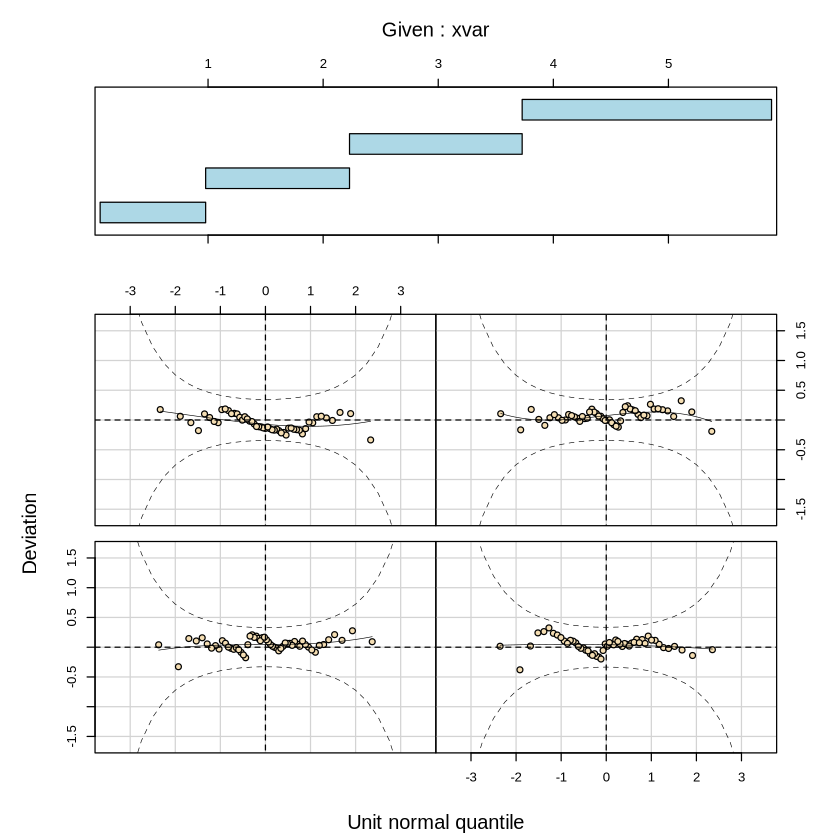

In [28]:
wp(model_const_tau1, xvar = data$age_year)

#### 4) dtop Function

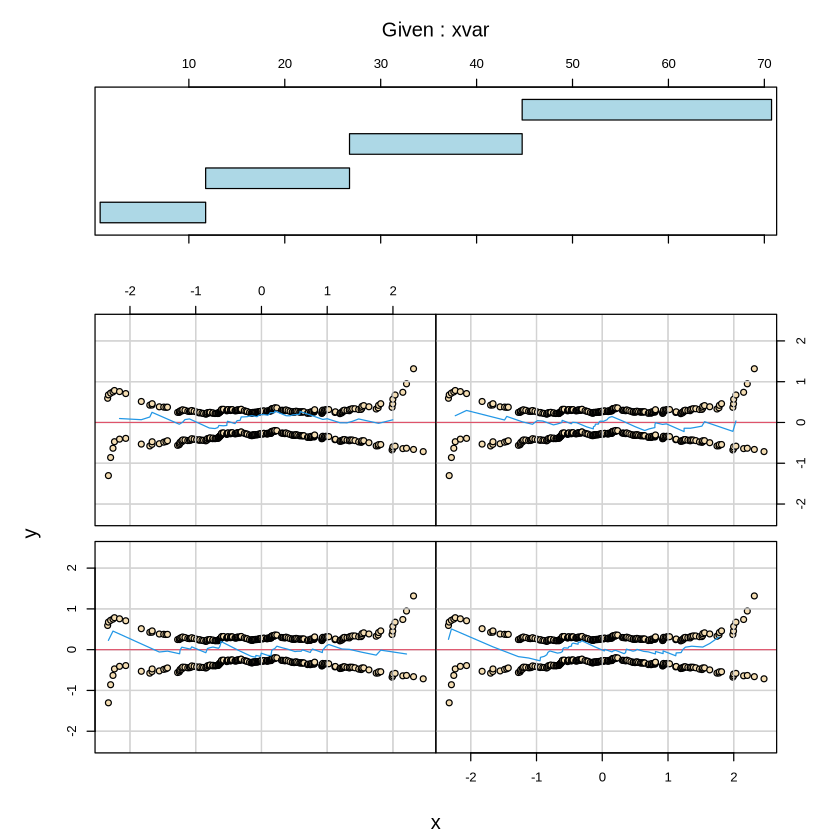

In [90]:
dtop(model_const_tau, xvar = data$age)

#### 5) Q.Stats

,Z1,Z2,Z3,Z4,AgostinoK2,N
0.75 to 6.75,-0.01554865,1.1864919,1.5247837,-0.61009198,2.6971774,24
6.75 to 10.75,1.26244316,-1.4798282,-2.5973264,2.56851360,13.3433667,23
10.75 to 15.75,-0.96177064,0.9436850,-0.5378462,0.15457743,0.3131727,27
15.75 to 22.75,-0.09435446,-0.9340138,0.9534280,-0.13829618,0.9281507,24
22.75 to 29.75,0.49858789,-0.4876541,0.2800782,-1.40862442,2.0626665,21
29.75 to 38.75,0.30061395,-0.6147838,0.4461070,0.88850135,0.9884461,24
38.75 to 46.75,0.06658809,0.3479576,0.3378013,-0.44197775,0.3094541,26
46.75 to 57.75,0.33736836,0.1759481,-0.7526120,-0.09707524,0.5758485,21
57.75 to 70.75,-0.09944996,0.2857651,0.4191236,0.25348504,0.2399193,23
TOTAL Q stats,2.99501033,6.2100372,11.4030276,10.05517438,21.4582020,213


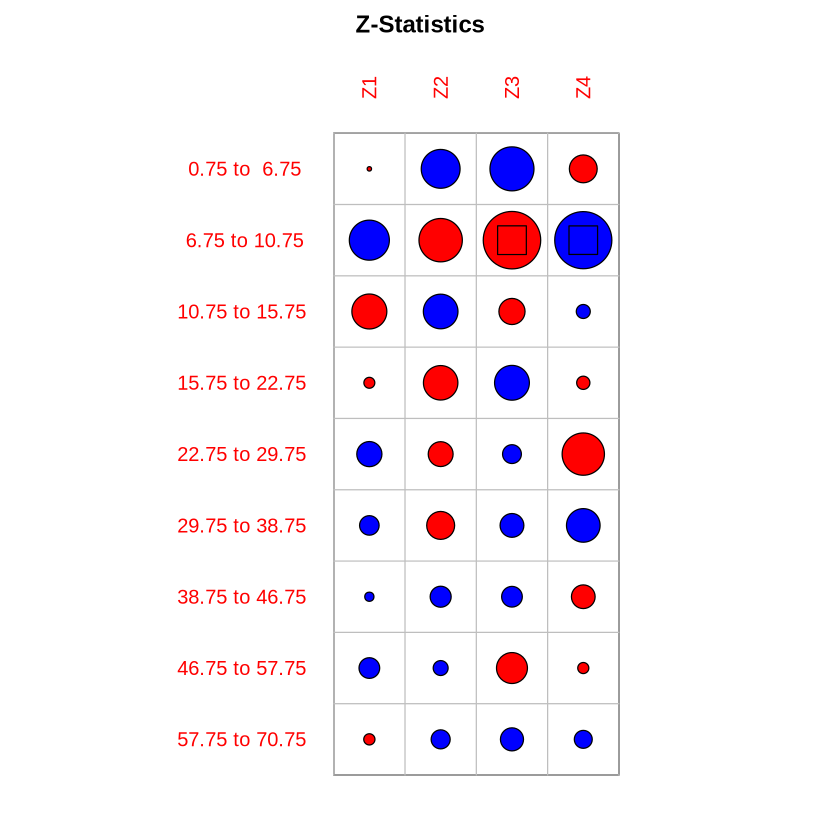

In [34]:
Q.stats(model_const_tau1, xvar = data$age, n.inter = 9)

#### 6) `rqres.plot()` function

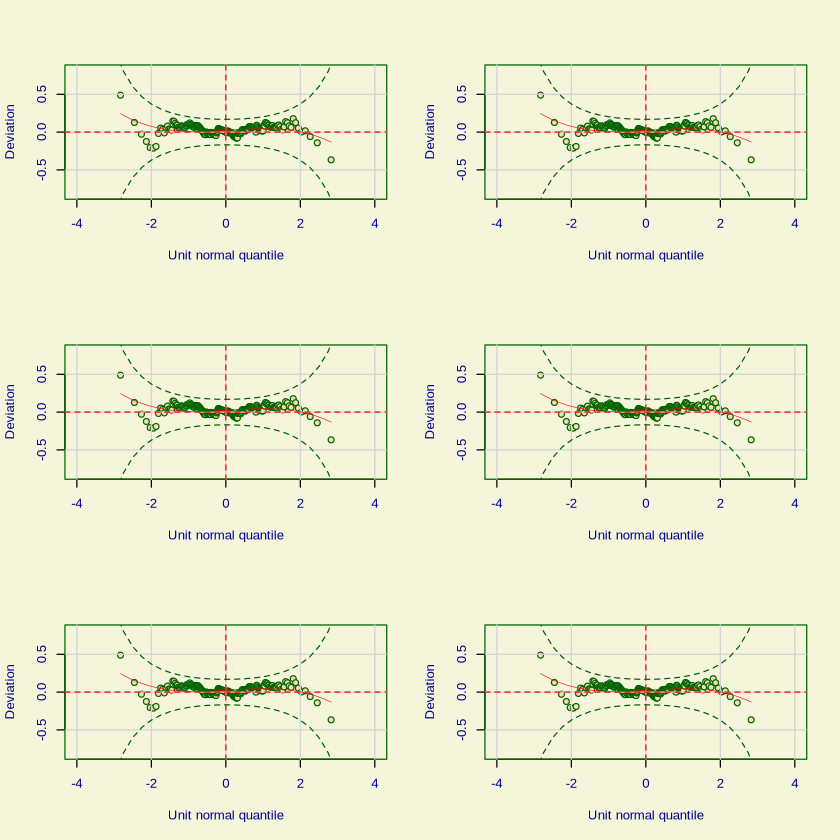

In [36]:
rqres.plot(model_const_tau1)

% of cases below  0.4 centile is  0 
% of cases below  2 centile is  3.286385 
% of cases below  10 centile is  7.511737 
% of cases below  25 centile is  22.53521 
% of cases below  50 centile is  50.23474 
% of cases below  75 centile is  73.23944 
% of cases below  90 centile is  88.73239 
% of cases below  98 centile is  98.12207 
% of cases below  99.6 centile is  100 


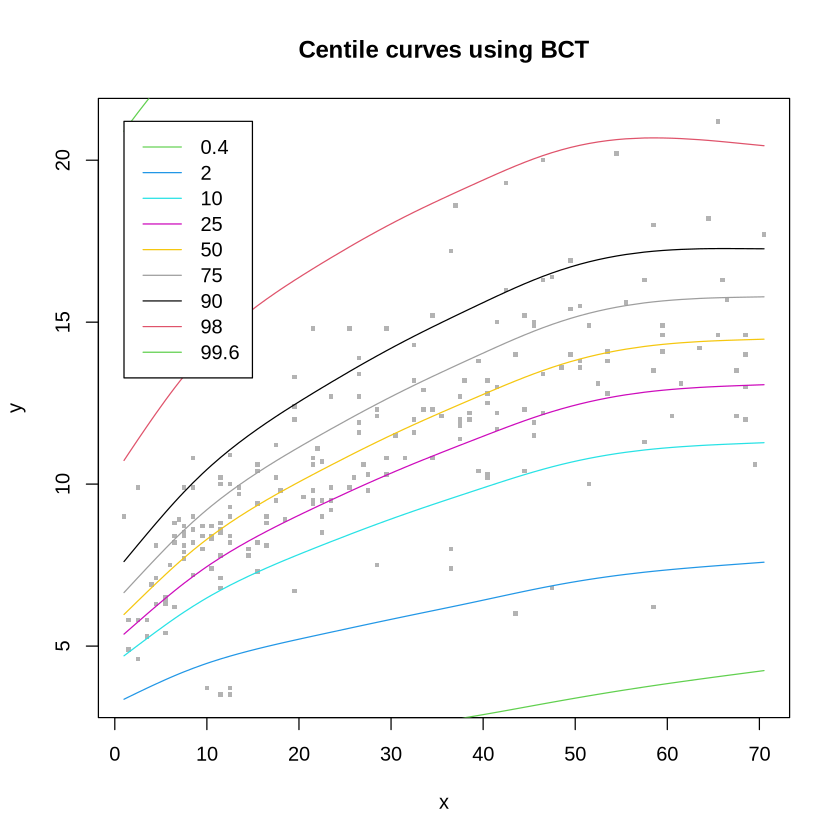

In [38]:
centiles(model_const_tau1, xvar = data$age)